# PEFT 库 QLoRA 实战 - ChatGLM4-69

通常，模型被量化后不会进一步训练用于下游任务，因为由于权重和激活的较低精度，训练可能不稳定。

但是由于PEFT方法只添加额外的可训练参数，这使得我们可以使用PEFT适配器（Adapter）来训练一个量化模型！将量化与PEFT结合起来可以成为在单个GPU上训练大模型的微调策略。


In [1]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HOME'] = '/hy-tmp'
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 定义全局变量和参数
model_name_or_path = 'THUDM/glm-4-9b-chat-hf'  # 模型ID或本地路径
train_data_path = 'HasturOfficial/adgen'       # 训练数据路径
max_length = 8192
output_dir = "./model_output/chatglm4_adgen_lora"

## 数据准备

### 下载数据集

从 Hugging Face 加载 adgen 数据集，并tokenize，shuffle

In [2]:
from datasets import load_dataset

dataset = load_dataset(train_data_path)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['content', 'summary'],
        num_rows: 114599
    })
    validation: Dataset({
        features: ['content', 'summary'],
        num_rows: 1070
    })
})

In [4]:
dataset["train"][2]

{'content': '类型#上衣*版型#宽松*颜色#粉红色*图案#字母*图案#文字*图案#线条*衣样式#卫衣*衣款式#不规则',
 'summary': '宽松的卫衣版型包裹着整个身材，宽大的衣身与身材形成鲜明的对比描绘出纤瘦的身形。下摆与袖口的不规则剪裁设计，彰显出时尚前卫的形态。被剪裁过的样式呈现出布条状自然地垂坠下来，别具有一番设计感。线条分明的字母样式有着花式的外观，棱角分明加上具有少女元气的枣红色十分有年轻活力感。粉红色的衣身把肌肤衬托得很白嫩又健康。'}

In [5]:
dataset["validation"][3]

{'content': '类型#裤*风格#英伦*风格#简约',
 'summary': '裤子是简约大方的版型设计，带来一种极简主义风格而且不乏舒适优雅感，是衣橱必不可少的一件百搭单品。标志性的logo可以体现出一股子浓郁的英伦风情，轻而易举带来独一无二的<UNK>体验。'}

### 数据预处理
- ***目标是生成input_id、label、attention_mask***

- ***token_process_func生成input_id和label, DataCollator负责pading、attention_mask、batch操作***

- ***LLM一般会对question在label中做ignore处理，在label中固定给 -100数值代替***

- ***LLM一般是左对齐不用右对齐，左边填充pad位置，在pad位置处，input是固定值，label会变为 -100，attention_mask置为0值***



In [6]:
from transformers import AutoTokenizer, DataCollatorForSeq2Seq

tokenizer = AutoTokenizer.from_pretrained('THUDM/glm-4-9b-chat-hf')

In [7]:
# 数据预处理函数 (重点：通用化写法)
def process_func(example):
    MAX_LENGTH = max_length
    input_ids, labels = [], []
    
    # 构建符合官方模板的对话格式
    instruction = "根据输入的关键词信息，写一段生动的电商广告文案。"
    messages = [
        {"role": "user", "content": f"{instruction}\n{example['content']}"},
        {"role": "assistant", "content": example['summary']}
    ]
    
    # 使用 apply_chat_template，add_generation_prompt=False 因为我们在训练
    # 这里将对话转为完整的 token id
    input_dict = tokenizer.apply_chat_template(messages, add_generation_prompt=False, tokenize=False)
    
    # 手动在字符串末尾加上 Tokenizer 定义的结束符，防止推理时变为复读机
    input_dict += tokenizer.eos_token
    
    # 这里的技巧是：先 tokenize 整个对话，再把 user 之前的文字全部 mask 掉
    # GLM-4 的模板中，assistant 内容开始之前会有特定的 token 标记
    # 我们通过查找这个标记来定位从哪里开始计算 Loss
    encoded = tokenizer(input_dict, add_special_tokens=False, truncation=True, max_length=MAX_LENGTH)
    input_ids = encoded["input_ids"]
    
    # 寻找 assistant 回复的起始位置（GLM-4 模板中辅助标记通常为特定的 token）
    # 一个通用的技巧是：再次 tokenize 用户部分，计算其长度
    user_messages = messages[:1]
    user_input_dict = tokenizer.apply_chat_template(user_messages, add_generation_prompt=True, tokenize=False)
    user_encoded = tokenizer(user_input_dict, add_special_tokens=False)
    user_len = len(user_encoded["input_ids"])
    
    # 构建 labels：用户部分用 -100 填充，助手部分保留原始 ID
    labels = [-100] * user_len + input_ids[user_len:]
    
    # 截断 labels 以匹配 input_ids
    if len(labels) > len(input_ids):
        labels = labels[:len(input_ids)]
    
    return {
        "input_ids": input_ids,
        "labels": labels
    }

# 加载并处理数据集
tokenized_dataset = dataset['train'].map(process_func, remove_columns=dataset['train'].column_names)

In [8]:
# 使用官方 DataCollator
# 它会自动帮你处理 Padding 和 Attention Mask，不再需要手写复杂的类
collator = DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True)

In [9]:
# 模拟从数据集取两条数据
samples = [tokenized_dataset[0], tokenized_dataset[1]]
# 手动执行一次 collator
batch = collator(samples)
print(batch.keys()) 
# 输出结果一定是: dict_keys(['input_ids', 'labels', 'attention_mask'])
print(batch['input_ids'][1],batch['labels'][1],batch['attention_mask'][1])
# 你会看到一串 1 和 0，0 的位置就是补齐产生的

dict_keys(['input_ids', 'attention_mask', 'labels'])
tensor([151329, 151329, 151329, 151329, 151329, 151329, 151329, 151331, 151333,
        151336,    198,  99245, 102010, 103623,  99151,  98870,   3837,  99032,
        101688, 120075, 103196, 100823, 111605,   8994, 100173,      2, 102409,
             9, 100988,      2, 109404,      9, 106401,      2, 118798,      9,
        106401,      2, 106272,      9, 106401,      2, 101806,  98581,      9,
        102409,  98604,      2,  99537, 100453, 102409,      9, 102409, 103147,
         98425,      2,  98479, 103147, 151337,    198, 105632,  98755,  98618,
        110888, 107019, 101776, 106272,   3837, 100512,  99589,  99747,  98604,
          3837, 100427,  98440,  98318, 103544,   1773,  98479, 103147,  98976,
          3837,  99972,  98825, 113779,   3837, 109404, 100620, 118798, 101977,
          3837, 101350,  98714,  98542,  98320,  99537, 102450, 102493, 105237,
        105797,   1773, 111653, 101806, 100704,  99537, 100453,  98

## 训练模型

### 加载 ChatGLM4-9B 量化模型

In [10]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
import torch
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# QLoRA 量化配置
bnb_config = BitsAndBytesConfig(load_in_4bit=True,
                              bnb_4bit_quant_type='nf4',
                              bnb_4bit_use_double_quant=True,
                              bnb_4bit_compute_dtype=torch.bfloat16)

model = AutoModelForCausalLM.from_pretrained(
    model_name_or_path,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

print(model)

Loading checkpoint shards: 100%|██████████| 4/4 [00:17<00:00,  4.46s/it]


GlmForCausalLM(
  (model): GlmModel(
    (embed_tokens): Embedding(151552, 4096, padding_idx=151329)
    (layers): ModuleList(
      (0-39): 40 x GlmDecoderLayer(
        (self_attn): GlmAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=True)
          (k_proj): Linear4bit(in_features=4096, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=4096, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): GlmMLP(
          (gate_up_proj): Linear4bit(in_features=4096, out_features=27392, bias=False)
          (down_proj): Linear4bit(in_features=13696, out_features=4096, bias=False)
          (activation_fn): SiLU()
        )
        (input_layernorm): GlmRMSNorm((4096,), eps=1.5625e-07)
        (post_attention_layernorm): GlmRMSNorm((4096,), eps=1.5625e-07)
      )
    )
    (norm): GlmRMSNorm((4096,), eps=1.5625e-07)
    (rotary_emb): GlmRotaryEmbedding()
  )

In [11]:
# 开启梯度检查点以节省显存
model.gradient_checkpointing_enable()
model.config.use_cache = False  #推理用，训练时关闭

kbit_model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_up_proj", "down_proj"],
    r = 4,
    lora_alpha = 32,
    lora_dropout = 0.1,
    bias = 'none',
    inference_mode = False,
    task_type = "CAUSAL_LM"
)

qlora_model = get_peft_model(kbit_model, lora_config)
qlora_model.print_trainable_parameters()

trainable params: 11,898,880 || all params: 9,411,850,240 || trainable%: 0.12642445105458883


### 开始训练模型

In [12]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir = output_dir,   # 输出目录
    per_device_train_batch_size = 16,                    # 每个设备的训练批量大小
    gradient_accumulation_steps = 4,                     # 梯度累积步数
    # per_device_eval_batch_size=8,                      # 每个设备的评估批量大小
    learning_rate = 1e-4,                                # 学习率
    num_train_epochs = 1.0,                              # 训练轮数
    warmup_steps = 100,                                  # 预热比例
    logging_steps = 80,                                  # 日志记录步数
    save_strategy = "steps",                             # 模型保存策略
    save_steps = 400,                                    # 模型保存步数
    save_on_each_node = True,
    gradient_checkpointing = True,
    dataloader_num_workers = 2,                          # DataLoader并行化，提升训练速度
    fp16 = True,                                         # 是否使用混合精度训练
    report_to = "tensorboard", # 方便监控使用
)

In [13]:
trainer = Trainer(
        model = qlora_model,
        args = training_args,
        train_dataset = tokenized_dataset,
        data_collator = collator
    )

In [14]:
# trainer.train()

In [15]:
# trainer.save_model(output_dir)

Step       | Epoch      | Train Loss  
----------------------------------------------------
80         | 0.04       | 12.9646      
160        | 0.09       | 11.5135      
240        | 0.13       | 11.3033      
320        | 0.18       | 11.2394      
400        | 0.22       | 11.1274      
480        | 0.27       | 11.0966      
560        | 0.31       | 11.0268      
640        | 0.36       | 10.9708      
720        | 0.40       | 10.9152      
800        | 0.45       | 10.8358      
880        | 0.49       | 10.8226      
960        | 0.54       | 10.7991      
1040       | 0.58       | 10.7377      
1120       | 0.63       | 10.7815      
1200       | 0.67       | 10.7575      
1280       | 0.71       | 10.7288      
1360       | 0.76       | 10.6845      
1440       | 0.80       | 10.6653      
1520       | 0.85       | 10.6751      
1600       | 0.89       | 10.6206      
1680       | 0.94       | 10.6452      
1760       | 0.98       | 10.5824      

图表已保存至: ./training_analysis

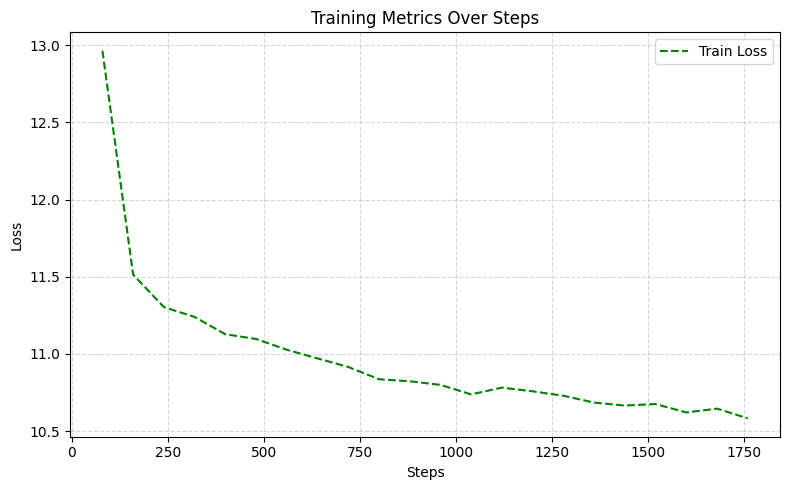

In [16]:
# 从训练保存的checkpoint文件里加载训练评估日志

import json
import pandas as pd
import matplotlib.pyplot as plt
import os

def analyze_trainer_logs(json_path, save_dir=None):
    # 1. 加载数据
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data['log_history'])
    
    # 2. 分离训练和评估数据
    # 训练行通常包含 'loss'，评估行包含 'eval_loss'
    train_df = df.dropna(subset=['loss']).copy()
    
    # 3. 打印简报
    print(f"{'Step':<10} | {'Epoch':<10} | {'Train Loss':<12}")
    print("-" * 52)
    
    # 合并数据查看（按 Step 对齐最近的记录）
    for _, row in train_df.iterrows():
        step = row['step']
        epoch = row['epoch']
        
        # 找到训练集中最接近该 step 的 train_loss
        matching_train = train_df[train_df['step'] <= step].iloc[-1] if not train_df.empty else None
        train_loss = matching_train['loss'] if matching_train is not None else "N/A"
        
        print(f"{int(step):<10} | {epoch:<10.2f} | {train_loss:<12.4f} ")

    # 4. 绘图
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # 左轴：绘制 Loss
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Loss')
    ax1.plot(train_df['step'], train_df['loss'], label='Train Loss', color='green',linestyle='--')
    ax1.tick_params(axis='y')
    ax1.legend(loc='upper right')
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.title('Training Metrics Over Steps')
    fig.tight_layout()
    
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'training_analysis.png'))
        print(f"\n图表已保存至: {os.path.join(save_dir, 'training_analysis.png')}")
    
    plt.show()

# --- 使用示例 ---
# 替换为你最新的那个 checkpoint 文件夹下的 json 路径
json_path = './model_output/chatglm4_adgen_lora/checkpoint-1790/trainer_state.json'
analyze_trainer_logs(json_path, save_dir="./")